Temperatura óptima: 30793.74 K
Potencia máxima: 3.514e+08 W/m^2


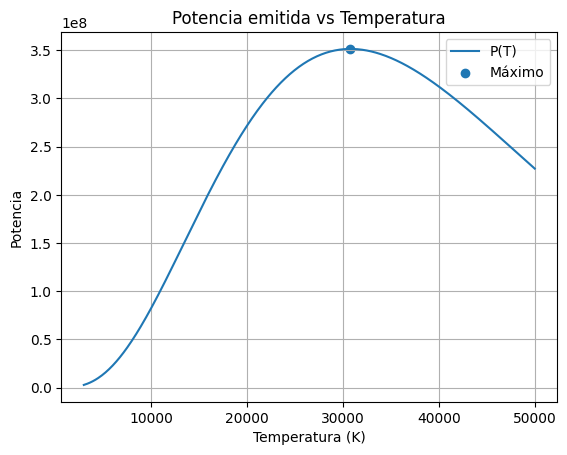

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
sigma = 5.67e-8
T0 = 10000

# Función P(T)
def P(T):
    return sigma * T**4 * np.exp(-T/T0) * (1 - np.exp(-5000/T))

# Para minimizar (negativo)
def f(T):
    return -P(T)

# Sección áurea
def golden_section(a, b, tol=50):
    gr = (np.sqrt(5) + 1) / 2  # razón áurea

    c = b - (b - a) / gr
    d = a + (b - a) / gr

    while abs(b - a) > tol:
        if f(c) < f(d):
            b = d
        else:
            a = c

        c = b - (b - a) / gr
        d = a + (b - a) / gr

    return (a + b) / 2

# Intervalo
a = 3000
b = 50000

# Encontrar máximo
T_opt = golden_section(a, b, tol=50)
P_opt = P(T_opt)

print(f"Temperatura óptima: {T_opt:.2f} K")
print(f"Potencia máxima: {P_opt:.3e} W/m^2")

# Graficar
T_vals = np.linspace(3000, 50000, 500)
P_vals = P(T_vals)

plt.figure()
plt.plot(T_vals, P_vals, label="P(T)")
plt.scatter(T_opt, P_opt, label="Máximo", marker='o')
plt.xlabel("Temperatura (K)")
plt.ylabel("Potencia")
plt.title("Potencia emitida vs Temperatura")
plt.legend()
plt.grid()

plt.show()

Radio de máxima pendiente r* = 0.100006 kpc


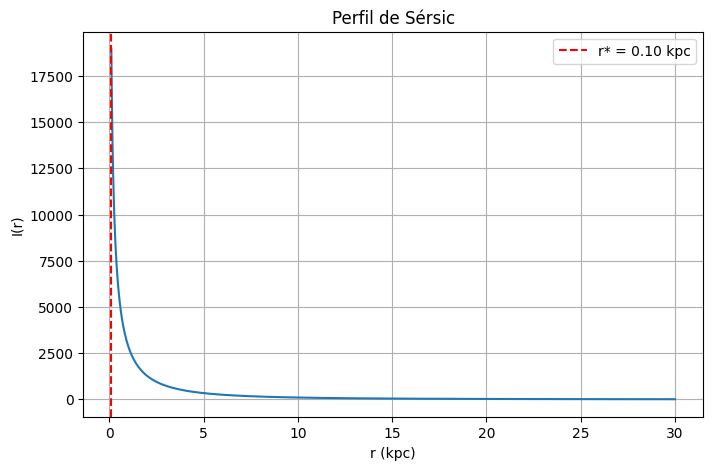

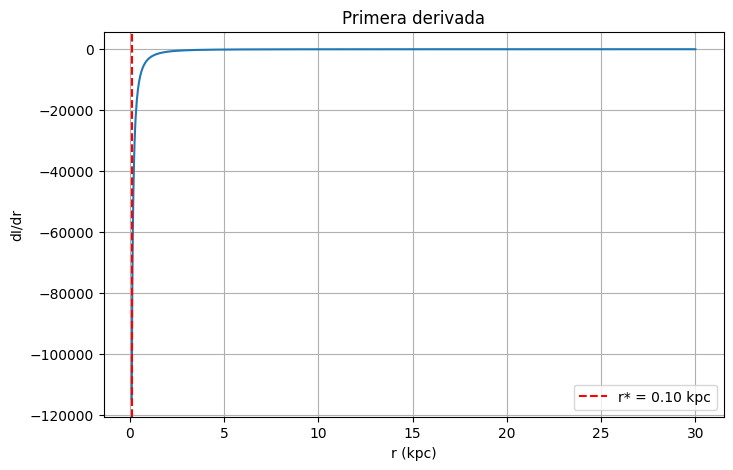

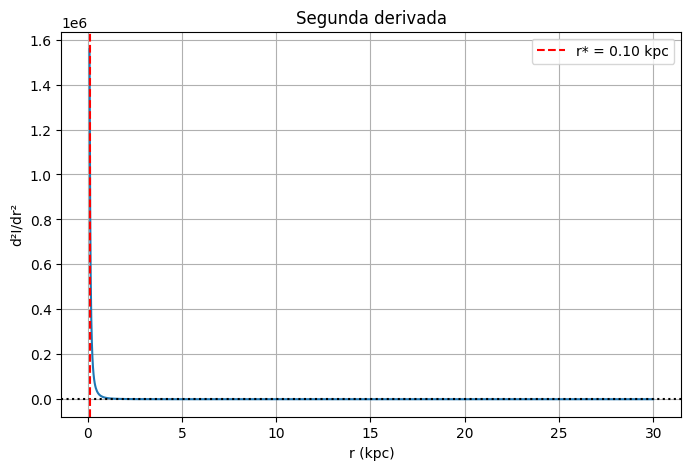

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Parámetros del perfil de Sérsic

n = 4
b = 7.669
re = 10.0      # kpc
I0 = 100.0

# Perfil de Sérsic

def I(r):

    return I0 * np.exp(
        -b * ((r/re)**(1/n) - 1)
    )

# Primera derivada numérica

def dI_dr(r, h=1e-5):

    return (I(r + h) - I(r - h)) / (2*h)

# Minimizar dI/dr

sol = minimize_scalar(
    dI_dr,
    bounds=(0.1, 30),
    method='bounded'
)

r_star = sol.x

print(f"Radio de máxima pendiente r* = {r_star:.6f} kpc")


# Segunda derivada numérica

def d2I_dr2(r, h=1e-5):

    return (I(r+h) - 2*I(r) + I(r-h)) / h**2


# Datos para gráficas

r_vals = np.linspace(0.1, 30, 1000)

I_vals = I(r_vals)

dI_vals = np.array([dI_dr(r) for r in r_vals])

d2I_vals = np.array([d2I_dr2(r) for r in r_vals])


# GRÁFICA 1 PERFIL

plt.figure(figsize=(8,5))

plt.plot(r_vals, I_vals)

plt.axvline(
    r_star,
    color='red',
    linestyle='--',
    label=f'r* = {r_star:.2f} kpc'
)

plt.xlabel('r (kpc)')
plt.ylabel('I(r)')
plt.title('Perfil de Sérsic')

plt.grid()
plt.legend()

plt.show()


#GRÁFICA 2 PRIMERA DERIVADA

plt.figure(figsize=(8,5))

plt.plot(r_vals, dI_vals)

plt.axvline(
    r_star,
    color='red',
    linestyle='--',
    label=f'r* = {r_star:.2f} kpc'
)

plt.xlabel('r (kpc)')
plt.ylabel('dI/dr')
plt.title('Primera derivada')

plt.grid()
plt.legend()

plt.show()

# GRÁFICA 3 SEGUNDA DERIVADA

plt.figure(figsize=(8,5))

plt.plot(r_vals, d2I_vals)

plt.axhline(
    0,
    color='black',
    linestyle=':'
)

plt.axvline(
    r_star,
    color='red',
    linestyle='--',
    label=f'r* = {r_star:.2f} kpc'
)

plt.xlabel('r (kpc)')
plt.ylabel('d²I/dr²')
plt.title('Segunda derivada')

plt.grid()
plt.legend()

plt.show()


El radio de máxima pendiente corresponde a la región donde el brillo superficial decrece más rápidamente con la distancia al centro galáctico.
En el perfil de Sérsic con n = 4 (perfil de de Vaucouleurs), la concentración central de luminosidad es muy alta, por lo que la pendiente más pronunciada aparece cerca de la región central.
Esto es característico de galaxias elípticas y bulbos galácticos, donde la intensidad luminosa disminuye abruptamente desde el núcleo hacia las regiones externas. 
El comportamiento singular cerca de r -> 0 es consecuencia de la idealización matemática del perfil de Sérsic.


Borrador de interpretación: 

El perfil de Sérsic con $n=4$ presenta una fuerte concentración central de luminosidad, causando una pendiente muy pronunciada cerca de $r=0$. Debido a ello, el mínimo absoluto de $\frac{dI}{dr}$ ocurre cerca del límite inferior del dominio. Para obtener un radio físicamente representativo de la estructura galáctica, delimité la búsqueda a radios mayores que la región singular central.

El radio de máxima pendiente (mínimo de dI/dr) corresponde a la región donde el brillo superficial decae más rápidamente con la distancia al centro. para un perfil de Sérsic con $n=4$ (ley de de Vaucouleurs), el decaimiento más abrupto ocurre en el centro mismo (r → 0). Esto es típico de galaxias elípticas y bulges, donde el brillo central es muy elevado y cae rápido.